In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import train_test_split


# =========================================================
# Названия признаков
# =========================================================

columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]


# =========================================================
# Загрузка данных
# =========================================================

train_data = pd.read_csv(
    'adult.data.txt',
    names=columns,
    skipinitialspace=True
)

test_data = pd.read_csv(
    'adult.test.txt',
    names=columns,
    skipinitialspace=True,
    skiprows=1
)


# =========================================================
# Очистка данных
# =========================================================

train_data = train_data.replace('?', np.nan).dropna()

test_data = test_data.replace('?', np.nan).dropna()


# В adult.test после значения income стоит точка
test_data['income'] = test_data['income'].str.replace(
    '.',
    '',
    regex=False
)


# =========================================================
# Объединяем train и test
# =========================================================

all_data = pd.concat(
    [train_data, test_data],
    ignore_index=True
)


# =========================================================
# Признаки
# =========================================================

feature_columns = [
    column
    for column in columns
    if column != 'income'
]


# =========================================================
# Кодирование всех признаков
# =========================================================

for column in feature_columns:

    # factorize переводит категории в числа:
    # Private -> 0
    # State-gov -> 1
    # Self-emp-not-inc -> 2
    # и т.д.

    all_data[column], categories = pd.factorize(
        all_data[column]
    )


# =========================================================
# Кодирование целевого признака income
# =========================================================

all_data['income'], income_categories = pd.factorize(
    all_data['income']
)


# =========================================================
# Разделяем обратно обучающую и тестовую выборки
# =========================================================

train_size = len(train_data)

train_encoded = all_data.iloc[
    :train_size
].copy()

test_encoded = all_data.iloc[
    train_size:
].copy()


# =========================================================
# Приводим данные к числовому типу
# =========================================================

train_encoded = train_encoded.astype(float)

test_encoded = test_encoded.astype(float)


# =========================================================
# Названия признаков
# =========================================================

feature_names = feature_columns


# =========================================================
# Проверка результата
# =========================================================

print('Данные успешно загружены.')

print(
    'Обучающая выборка:',
    train_encoded.shape
)

print(
    'Тестовая выборка:',
    test_encoded.shape
)

print(
    'Количество признаков:',
    len(feature_names)
)


print('\nТипы данных:')

print(
    train_encoded.dtypes
)


print('\nСтроковые столбцы:')

print(
    train_encoded.select_dtypes(
        include=['object', 'string', 'category']
    ).columns.tolist()
)


print('\nПервые 5 строк после кодирования:')

display(
    train_encoded.head()
)

Данные успешно загружены.
Обучающая выборка: (30162, 15)
Тестовая выборка: (15060, 15)
Количество признаков: 14

Типы данных:
age               float64
workclass         float64
fnlwgt            float64
education         float64
education-num     float64
marital-status    float64
occupation        float64
relationship      float64
race              float64
sex               float64
capital-gain      float64
capital-loss      float64
hours-per-week    float64
native-country    float64
income            float64
dtype: object

Строковые столбцы:
[]

Первые 5 строк после кодирования:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2.0,2.0,2.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3.0,2.0,3.0,2.0,2.0,1.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,4.0,2.0,4.0,0.0,0.0,1.0,3.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [14]:
# =========================================================
# Ячейка 2. Алгоритм дерева решений
# =========================================================

# ---------------------------------------------------------
# Энтропия
# ---------------------------------------------------------

def entropy(y):

    if len(y) == 0:
        return 0.0

    _, counts = np.unique(
        y,
        return_counts=True
    )

    probabilities = counts / len(y)

    return -np.sum(
        probabilities * np.log2(
            probabilities + 1e-12
        )
    )


# ---------------------------------------------------------
# Индекс Джини
# ---------------------------------------------------------

def gini_index(y):

    if len(y) == 0:
        return 0.0

    _, counts = np.unique(
        y,
        return_counts=True
    )

    probabilities = counts / len(y)

    return 1.0 - np.sum(
        probabilities ** 2
    )


# ---------------------------------------------------------
# Information Gain
# ---------------------------------------------------------

def information_gain(
    y,
    left_y,
    right_y
):

    if len(left_y) == 0 or len(right_y) == 0:
        return -np.inf

    parent_entropy = entropy(y)

    left_weight = len(left_y) / len(y)
    right_weight = len(right_y) / len(y)

    children_entropy = (
        left_weight * entropy(left_y)
        + right_weight * entropy(right_y)
    )

    return (
        parent_entropy
        - children_entropy
    )


# ---------------------------------------------------------
# Gain Ratio
# ---------------------------------------------------------

def gain_ratio(
    y,
    left_y,
    right_y
):

    if len(left_y) == 0 or len(right_y) == 0:
        return -np.inf

    gain = information_gain(
        y,
        left_y,
        right_y
    )

    left_weight = len(left_y) / len(y)
    right_weight = len(right_y) / len(y)

    split_info = 0.0

    if left_weight > 0:
        split_info -= (
            left_weight
            * np.log2(left_weight)
        )

    if right_weight > 0:
        split_info -= (
            right_weight
            * np.log2(right_weight)
        )

    if split_info == 0:
        return 0.0

    return gain / split_info


# ---------------------------------------------------------
# Улучшение по индексу Джини
# ---------------------------------------------------------

def gini_gain(
    y,
    left_y,
    right_y
):

    if len(left_y) == 0 or len(right_y) == 0:
        return -np.inf

    parent_gini = gini_index(y)

    left_weight = len(left_y) / len(y)
    right_weight = len(right_y) / len(y)

    children_gini = (
        left_weight * gini_index(left_y)
        + right_weight * gini_index(right_y)
    )

    return (
        parent_gini
        - children_gini
    )


# ---------------------------------------------------------
# Поиск лучшего разделения
# ---------------------------------------------------------

def find_best_split(
    X,
    y,
    criterion,
    max_candidates=20
):

    best_score = -np.inf
    best_feature = None
    best_threshold = None

    n_samples, n_features = X.shape

    if n_samples < 2:
        return None, None, best_score

    for feature_index in range(n_features):

        values = X[:, feature_index]

        unique_values = np.unique(values)

        if len(unique_values) < 2:
            continue

        # Для ускорения ограничиваем
        # количество проверяемых порогов

        if len(unique_values) > max_candidates + 1:

            quantiles = np.linspace(
                0.05,
                0.95,
                max_candidates
            )

            thresholds = np.unique(
                np.quantile(
                    values,
                    quantiles
                )
            )

        else:

            thresholds = (
                unique_values[:-1]
                + unique_values[1:]
            ) / 2.0

        for threshold in thresholds:

            left_mask = values <= threshold
            right_mask = values > threshold

            if (
                np.sum(left_mask) == 0
                or np.sum(right_mask) == 0
            ):
                continue

            left_y = y[left_mask]
            right_y = y[right_mask]

            if criterion == 'information_gain':

                score = information_gain(
                    y,
                    left_y,
                    right_y
                )

            elif criterion == 'gain_ratio':

                score = gain_ratio(
                    y,
                    left_y,
                    right_y
                )

            elif criterion == 'gini':

                score = gini_gain(
                    y,
                    left_y,
                    right_y
                )

            else:

                raise ValueError(
                    'Неизвестный критерий: '
                    + str(criterion)
                )

            if score > best_score:

                best_score = score
                best_feature = feature_index
                best_threshold = threshold

    return (
        best_feature,
        best_threshold,
        best_score
    )


# ---------------------------------------------------------
# Узел дерева
# ---------------------------------------------------------

class TreeNode:

    def __init__(
        self,
        prediction=None,
        feature=None,
        threshold=None,
        left=None,
        right=None
    ):

        self.prediction = prediction
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right


# ---------------------------------------------------------
# Построение дерева
# ---------------------------------------------------------

def build_custom_tree(
    X,
    y,
    criterion,
    depth=0,
    max_depth=8,
    min_samples=30
):

    # Определяем наиболее частый класс

    classes, counts = np.unique(
        y,
        return_counts=True
    )

    majority_class = classes[
        np.argmax(counts)
    ]

    # Все объекты относятся к одному классу

    if len(classes) == 1:

        return TreeNode(
            prediction=majority_class
        )

    # Достигнута максимальная глубина

    if depth >= max_depth:

        return TreeNode(
            prediction=majority_class
        )

    # Слишком мало объектов

    if len(y) < min_samples:

        return TreeNode(
            prediction=majority_class
        )

    # Ищем лучшее разделение

    feature_index, threshold, score = find_best_split(
        X,
        y,
        criterion
    )

    # Разделение не найдено

    if feature_index is None:

        return TreeNode(
            prediction=majority_class
        )

    # Разделение не улучшает качество

    if score <= 0:

        return TreeNode(
            prediction=majority_class
        )

    values = X[:, feature_index]

    left_mask = values <= threshold
    right_mask = values > threshold

    if (
        np.sum(left_mask) == 0
        or np.sum(right_mask) == 0
    ):

        return TreeNode(
            prediction=majority_class
        )

    # Строим левую ветвь

    left_tree = build_custom_tree(
        X[left_mask],
        y[left_mask],
        criterion,
        depth + 1,
        max_depth,
        min_samples
    )

    # Строим правую ветвь

    right_tree = build_custom_tree(
        X[right_mask],
        y[right_mask],
        criterion,
        depth + 1,
        max_depth,
        min_samples
    )

    return TreeNode(
        prediction=majority_class,
        feature=feature_index,
        threshold=threshold,
        left=left_tree,
        right=right_tree
    )


# ---------------------------------------------------------
# Предсказание одного объекта
# ---------------------------------------------------------

def predict_one(node, x):

    if node.feature is None:

        return node.prediction

    if x[node.feature] <= node.threshold:

        return predict_one(
            node.left,
            x
        )

    return predict_one(
        node.right,
        x
    )


# ---------------------------------------------------------
# Предсказания для всей выборки
# ---------------------------------------------------------

def predict_tree(tree, X):

    return np.array([
        predict_one(tree, row)
        for row in X
    ])


# ---------------------------------------------------------
# Расчёт метрик
# ---------------------------------------------------------

def evaluate_tree(
    tree,
    X_test,
    y_test
):

    predictions = predict_tree(
        tree,
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


# ---------------------------------------------------------
# Текстовое представление дерева
# ---------------------------------------------------------

def tree_to_text(
    node,
    feature_names,
    depth=0,
    max_lines=80
):

    lines = []

    def add_node(current, level):

        if len(lines) >= max_lines:
            return

        indent = '    ' * level

        if current.feature is None:

            lines.append(
                indent
                + 'Класс: '
                + str(current.prediction)
            )

            return

        feature_name = feature_names[
            current.feature
        ]

        lines.append(
            indent
            + f'{feature_name} <= '
            + f'{current.threshold:.3f}'
        )

        lines.append(
            indent + '├── Да'
        )

        add_node(
            current.left,
            level + 1
        )

        if len(lines) >= max_lines:
            return

        lines.append(
            indent + '└── Нет'
        )

        add_node(
            current.right,
            level + 1
        )

    add_node(
        node,
        depth
    )

    return '\n'.join(
        lines[:max_lines]
    )


# ---------------------------------------------------------
# Запуск эксперимента
# ---------------------------------------------------------

def run_experiment(
    train_df,
    test_df,
    criterion,
    train_share=1.0
):

    X_train_full = train_df[
        feature_columns
    ].values.astype(float)

    y_train_full = train_df[
        'income'
    ].values.astype(int)

    X_test = test_df[
        feature_columns
    ].values.astype(float)

    y_test = test_df[
        'income'
    ].values.astype(int)

    # Используем указанную долю
    # обучающей выборки

    if train_share < 1.0:

        X_train, _, y_train, _ = train_test_split(
            X_train_full,
            y_train_full,
            train_size=train_share,
            random_state=42,
            stratify=y_train_full
        )

    else:

        X_train = X_train_full
        y_train = y_train_full

    # Строим дерево

    tree = build_custom_tree(
        X_train,
        y_train,
        criterion=criterion,
        max_depth=8,
        min_samples=30
    )

    # Рассчитываем метрики

    metrics = evaluate_tree(
        tree,
        X_test,
        y_test
    )

    metrics['criterion'] = criterion
    metrics['train_share'] = train_share

    return tree, metrics


print('Ячейка 2 выполнена успешно.')
print('Функции дерева решений готовы.')

Ячейка 2 выполнена успешно.
Функции дерева решений готовы.


In [15]:
# =========================================================
# Ячейка 3. Сравнение трёх критериев
# =========================================================

criteria = [
    'information_gain',
    'gain_ratio',
    'gini'
]

results = []
trees = {}


for criterion in criteria:

    print()
    print('======================================')
    print('Обучение:', criterion)
    print('======================================')

    tree, result = run_experiment(
        train_encoded,
        test_encoded,
        criterion=criterion,
        train_share=1.0
    )

    trees[criterion] = tree
    results.append(result)

    print(
        f"Accuracy:  {result['accuracy'] * 100:.2f}%"
    )

    print(
        f"Precision: {result['precision'] * 100:.2f}%"
    )

    print(
        f"Recall:    {result['recall'] * 100:.2f}%"
    )

    print(
        f"F1:        {result['f1'] * 100:.2f}%"
    )


# =========================================================
# Таблица результатов
# =========================================================

results_df = pd.DataFrame(results)

results_df['accuracy'] = (
    results_df['accuracy'] * 100
)

results_df['precision'] = (
    results_df['precision'] * 100
)

results_df['recall'] = (
    results_df['recall'] * 100
)

results_df['f1'] = (
    results_df['f1'] * 100
)

results_df = results_df.round(2)


print()
print('Результаты сравнения критериев:')

display(results_df)


Обучение: information_gain
Accuracy:  83.92%
Precision: 69.80%
Recall:    60.92%
F1:        65.06%

Обучение: gain_ratio
Accuracy:  81.57%
Precision: 92.78%
Recall:    27.11%
F1:        41.96%

Обучение: gini
Accuracy:  84.10%
Precision: 70.35%
Recall:    60.97%
F1:        65.33%

Результаты сравнения критериев:


,accuracy,precision,recall,f1,criterion,train_share
0,83.92,69.80,60.92,65.06,information_gain,1.0
1,81.57,92.78,27.11,41.96,gain_ratio,1.0
2,84.10,70.35,60.97,65.33,gini,1.0


In [16]:
# =========================================================
# Ячейка 4. Эксперимент с разными соотношениями выборок
# =========================================================

# Объединяем обучающую и тестовую выборки
full_data = pd.concat(
    [
        train_encoded,
        test_encoded
    ],
    ignore_index=True
)


# Признаки и целевая переменная
X_full = full_data[
    feature_columns
].values.astype(float)

y_full = full_data[
    'income'
].values.astype(int)


# Фиксируем лучший критерий
# по результатам предыдущего эксперимента
fixed_criterion = 'gini'


# Соотношения обучающей и тестовой выборок
train_ratios = [
    0.60,
    0.70,
    0.80,
    0.90
]


ratio_results = []
ratio_trees = {}


# =========================================================
# Обучение для каждого соотношения
# =========================================================

for train_ratio in train_ratios:

    test_ratio = 1 - train_ratio

    print()
    print('======================================')
    print(
        f'Соотношение: '
        f'{int(train_ratio * 100)}:'
        f'{int(test_ratio * 100)}'
    )
    print('======================================')

    # Разделяем весь набор данных
    X_train, X_test, y_train, y_test = train_test_split(
        X_full,
        y_full,
        train_size=train_ratio,
        random_state=42,
        stratify=y_full
    )

    # Строим дерево
    tree = build_custom_tree(
        X_train,
        y_train,
        criterion=fixed_criterion,
        max_depth=8,
        min_samples=30
    )

    # Сохраняем дерево
    ratio_trees[train_ratio] = tree

    # Оцениваем качество
    metrics = evaluate_tree(
        tree,
        X_test,
        y_test
    )

    # Сохраняем результаты
    result = {
        'ratio': (
            f'{int(train_ratio * 100)}:'
            f'{int(test_ratio * 100)}'
        ),
        'accuracy': metrics['accuracy'] * 100,
        'precision': metrics['precision'] * 100,
        'recall': metrics['recall'] * 100,
        'f1': metrics['f1'] * 100
    }

    ratio_results.append(result)

    print(
        f"Accuracy:  {result['accuracy']:.2f}%"
    )

    print(
        f"Precision: {result['precision']:.2f}%"
    )

    print(
        f"Recall:    {result['recall']:.2f}%"
    )

    print(
        f"F1:        {result['f1']:.2f}%"
    )


# =========================================================
# Таблица результатов
# =========================================================

ratio_df = pd.DataFrame(
    ratio_results
)

ratio_df = ratio_df.round(2)


print()
print('Результаты эксперимента:')

display(ratio_df)


Соотношение: 60:40
Accuracy:  83.84%
Precision: 71.78%
Recall:    57.31%
F1:        63.73%

Соотношение: 70:30
Accuracy:  84.30%
Precision: 74.16%
Recall:    56.25%
F1:        63.97%

Соотношение: 80:19
Accuracy:  84.16%
Precision: 73.86%
Recall:    55.84%
F1:        63.60%

Соотношение: 90:9
Accuracy:  84.32%
Precision: 74.07%
Recall:    56.56%
F1:        64.14%

Результаты эксперимента:


,ratio,accuracy,precision,recall,f1
0,60:40,83.84,71.78,57.31,63.73
1,70:30,84.30,74.16,56.25,63.97
2,80:19,84.16,73.86,55.84,63.60
3,90:9,84.32,74.07,56.56,64.14


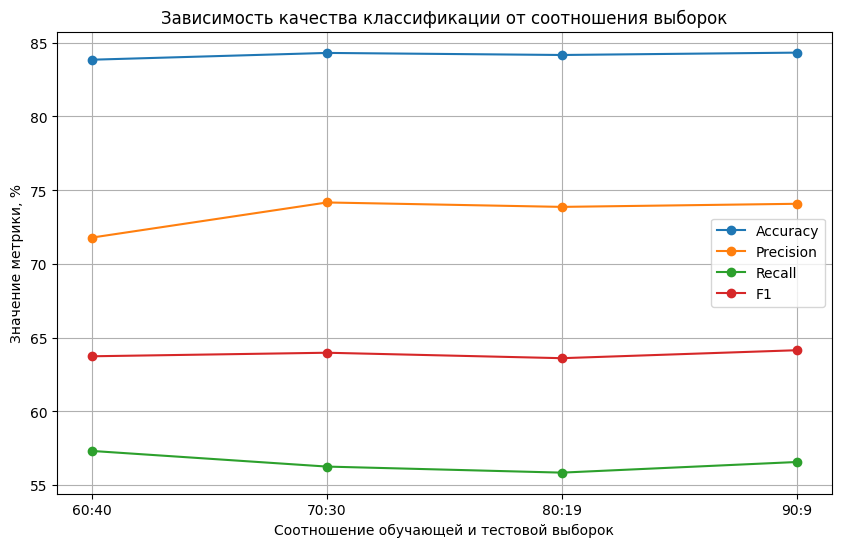

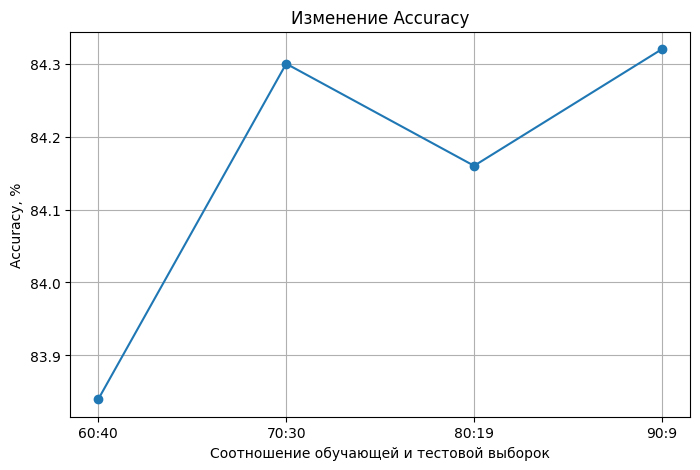

In [17]:
# =========================================================
# Ячейка 5. Визуализация результатов
# =========================================================

# ---------------------------------------------------------
# График всех метрик
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    ratio_df['ratio'],
    ratio_df['accuracy'],
    marker='o',
    label='Accuracy'
)

plt.plot(
    ratio_df['ratio'],
    ratio_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    ratio_df['ratio'],
    ratio_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    ratio_df['ratio'],
    ratio_df['f1'],
    marker='o',
    label='F1'
)

plt.xlabel(
    'Соотношение обучающей и тестовой выборок'
)

plt.ylabel(
    'Значение метрики, %'
)

plt.title(
    'Зависимость качества классификации '
    'от соотношения выборок'
)

plt.grid(True)
plt.legend()

plt.show()


# ---------------------------------------------------------
# График Accuracy
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    ratio_df['ratio'],
    ratio_df['accuracy'],
    marker='o'
)

plt.xlabel(
    'Соотношение обучающей и тестовой выборок'
)

plt.ylabel(
    'Accuracy, %'
)

plt.title(
    'Изменение Accuracy'
)

plt.grid(True)

plt.show()

In [18]:
# =========================================================
# Ячейка 6. Визуализация дерева решений
# =========================================================

# Берём дерево, построенное с использованием Gini Index
tree = trees['gini']


# Получаем текстовое представление дерева
tree_text = tree_to_text(
    tree,
    feature_names,
    max_lines=80
)


print('Дерево решений (Gini Index):')
print()
print(tree_text)

Дерево решений (Gini Index):

marital-status <= 0.500
├── Да
    capital-gain <= 1.000
    ├── Да
        relationship <= 1.500
        ├── Да
            occupation <= 3.500
            ├── Да
                education <= 7.500
                ├── Да
                    occupation <= 0.500
                    ├── Да
                        age <= 10.000
                        ├── Да
                            native-country <= 24.000
                            ├── Да
                                Класс: 0
                            └── Нет
                                Класс: 1
                        └── Нет
                            education <= 0.500
                            ├── Да
                                Класс: 0
                            └── Нет
                                Класс: 0
                    └── Нет
                        age <= 18.000
                        ├── Да
                            age <= 14.500
                            ├── Да


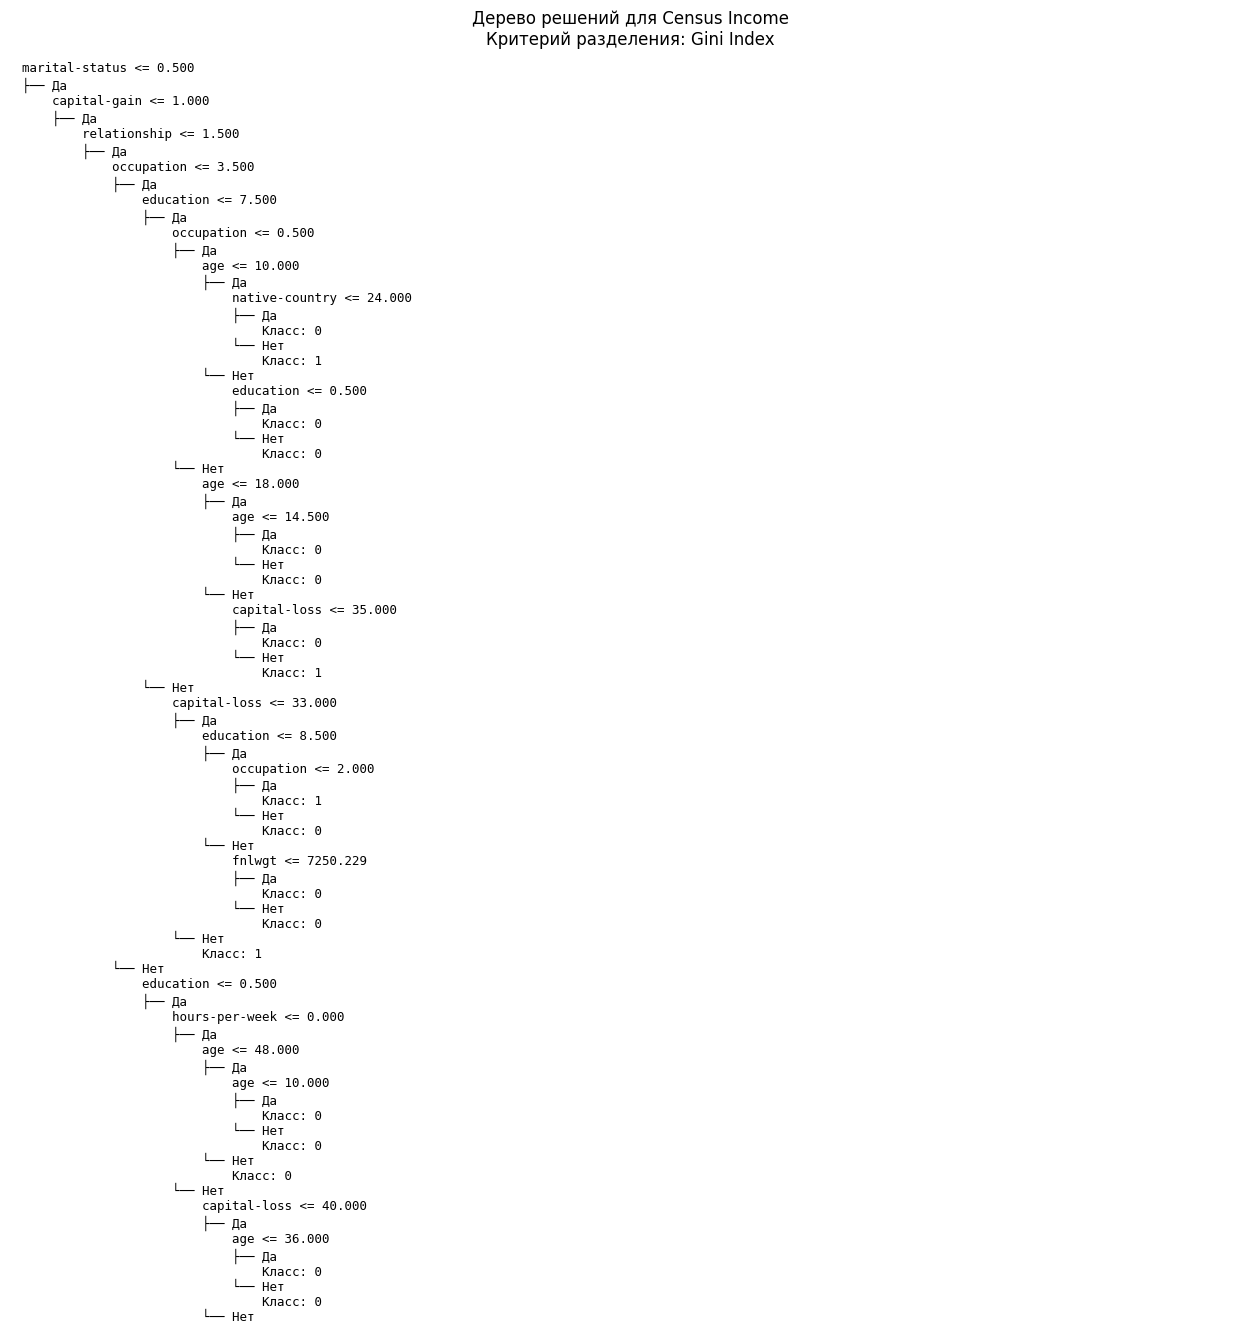

In [19]:
# =========================================================
# Ячейка 7. Графическое представление дерева
# =========================================================

plt.figure(figsize=(16, 12))

plt.text(
    0.01,
    0.99,
    tree_text,
    fontsize=9,
    verticalalignment='top',
    family='monospace'
)

plt.axis('off')

plt.title(
    'Дерево решений для Census Income\n'
    'Критерий разделения: Gini Index'
)

plt.show()